### Mean Shift Clustring
Mean shift clustering using a flat kernel.

Mean shift clustering aims to discover "blobs" in a smooth density of samples. It is a centroid-based algorithm, which works by updating candidates for centroids to be the mean of the points within a given region. These candidates are then filtered in a post-processing stage to eliminate near-duplicates to form the final set of centroids.

What Mean Shift is doing is shifting the windows to a higher density region by shifting their centroid (center of the sliding window) to the mean of the data-points inside the sliding window. 

In [136]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import MeanShift

### Data Preparation

In [137]:
data = pd.read_csv("../../data/Mall_Customers.csv")
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [138]:
data = data.drop(columns=["CustomerID","Age","Gender"])
data.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [140]:
data["X"] = data["Annual Income (k$)"]
data["Y"] = data["Spending Score (1-100)"]

In [141]:
data = data.drop(columns=["Annual Income (k$)","Spending Score (1-100)"])

In [142]:
data.head()

,X,Y
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


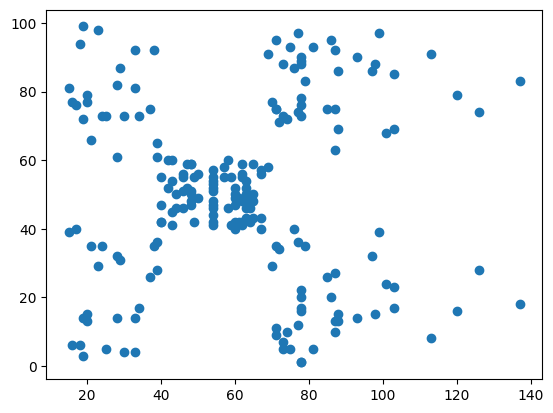

In [143]:
plt.scatter(data["X"],data["Y"])

In [125]:
MS = MeanShift(cluster_all=False,bandwidth=13,n_jobs=5)

In [126]:
MS.fit(data[["X"]],data[["Y"]])

MeanShift(bandwidth=13, cluster_all=False, n_jobs=5)

In [127]:
clusters = MS.predict(data[["X"]])

In [128]:
np.unique(clusters)

array([0, 1, 2, 3, 4], dtype=int64)

In [129]:
data["cluster"] = clusters

In [130]:
df1=data[data["cluster"] == 0]
df2=data[data["cluster"] == 1]
df3=data[data["cluster"] == 2]
df4=data[data["cluster"] == 3]
df5=data[data["cluster"] == 4]
noise = data[data["cluster"] == -1]

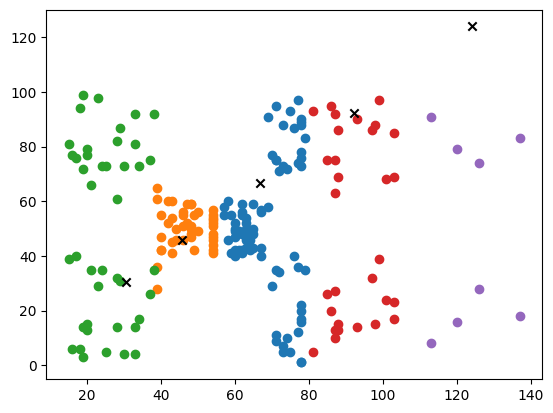

In [131]:
plt.scatter(df1["X"],df1["Y"])
plt.scatter(df2["X"],df2["Y"])
plt.scatter(df3["X"],df3["Y"])
plt.scatter(df4["X"],df4["Y"])
plt.scatter(df5["X"],df5["Y"])
plt.scatter(MS.cluster_centers_[:,0],MS.cluster_centers_[:,0],marker="x",c="black")
plt.scatter(noise["X"],noise["Y"],c="skyblue")

In [132]:
MS.cluster_centers_

array([[ 66.77272727],
       [ 45.72413793],
       [ 30.6       ],
       [ 92.2       ],
       [124.        ]])